In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import tukeylambda
import os

In [2]:
participant_name = "addie"

In [3]:
base_dir = "/Users/vidhyakshayakannan/Documents/Temporal-Attention"
data_dir = os.path.join(base_dir, "data", "raw", participant_name)

file_paths = [
    os.path.join(data_dir, f"{participant_name}1.1.csv"),
    os.path.join(data_dir, f"{participant_name}1.2.csv"),
    os.path.join(data_dir, f"{participant_name}1.3.csv")
]

for file in file_paths:
    if not os.path.exists(file):
        print(f"Error: {file} does not exist.")
        exit()

df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)
df['Key'] = df['Key'].astype(str)

correct_1_M = ((df["Tone"] == 1) & (df["Key"] == "M")).sum()
correct_2_C = ((df["Tone"] == 2) & (df["Key"] == "C")).sum()

total_1_M = (df["Tone"] == 1).sum()
total_2_C = (df["Tone"] == 2).sum()
total_count = len(df)

accuracy_1_M = (correct_1_M / total_1_M) * 100 if total_1_M > 0 else 0
accuracy_2_C = (correct_2_C / total_2_C) * 100 if total_2_C > 0 else 0

correct_count = correct_1_M + correct_2_C
incorrect_count = total_count - correct_count
overall_accuracy = (correct_count / total_count) * 100 if total_count > 0 else 0

print(f"Participant: {participant_name.capitalize()}")
print(f"In-tune correct: {correct_1_M} / {total_1_M} ({accuracy_1_M:.2f}%)")
print(f"Out-of-tune correct: {correct_2_C} / {total_2_C} ({accuracy_2_C:.2f}%)")
print(f"Correct responses: {correct_count}")
print(f"Incorrect responses: {incorrect_count}")
print(f"Overall accuracy: {overall_accuracy:.2f}%")

Participant: Addie
In-tune correct: 110 / 138 (79.71%)
Out-of-tune correct: 107 / 138 (77.54%)
Correct responses: 217
Incorrect responses: 59
Overall accuracy: 78.62%


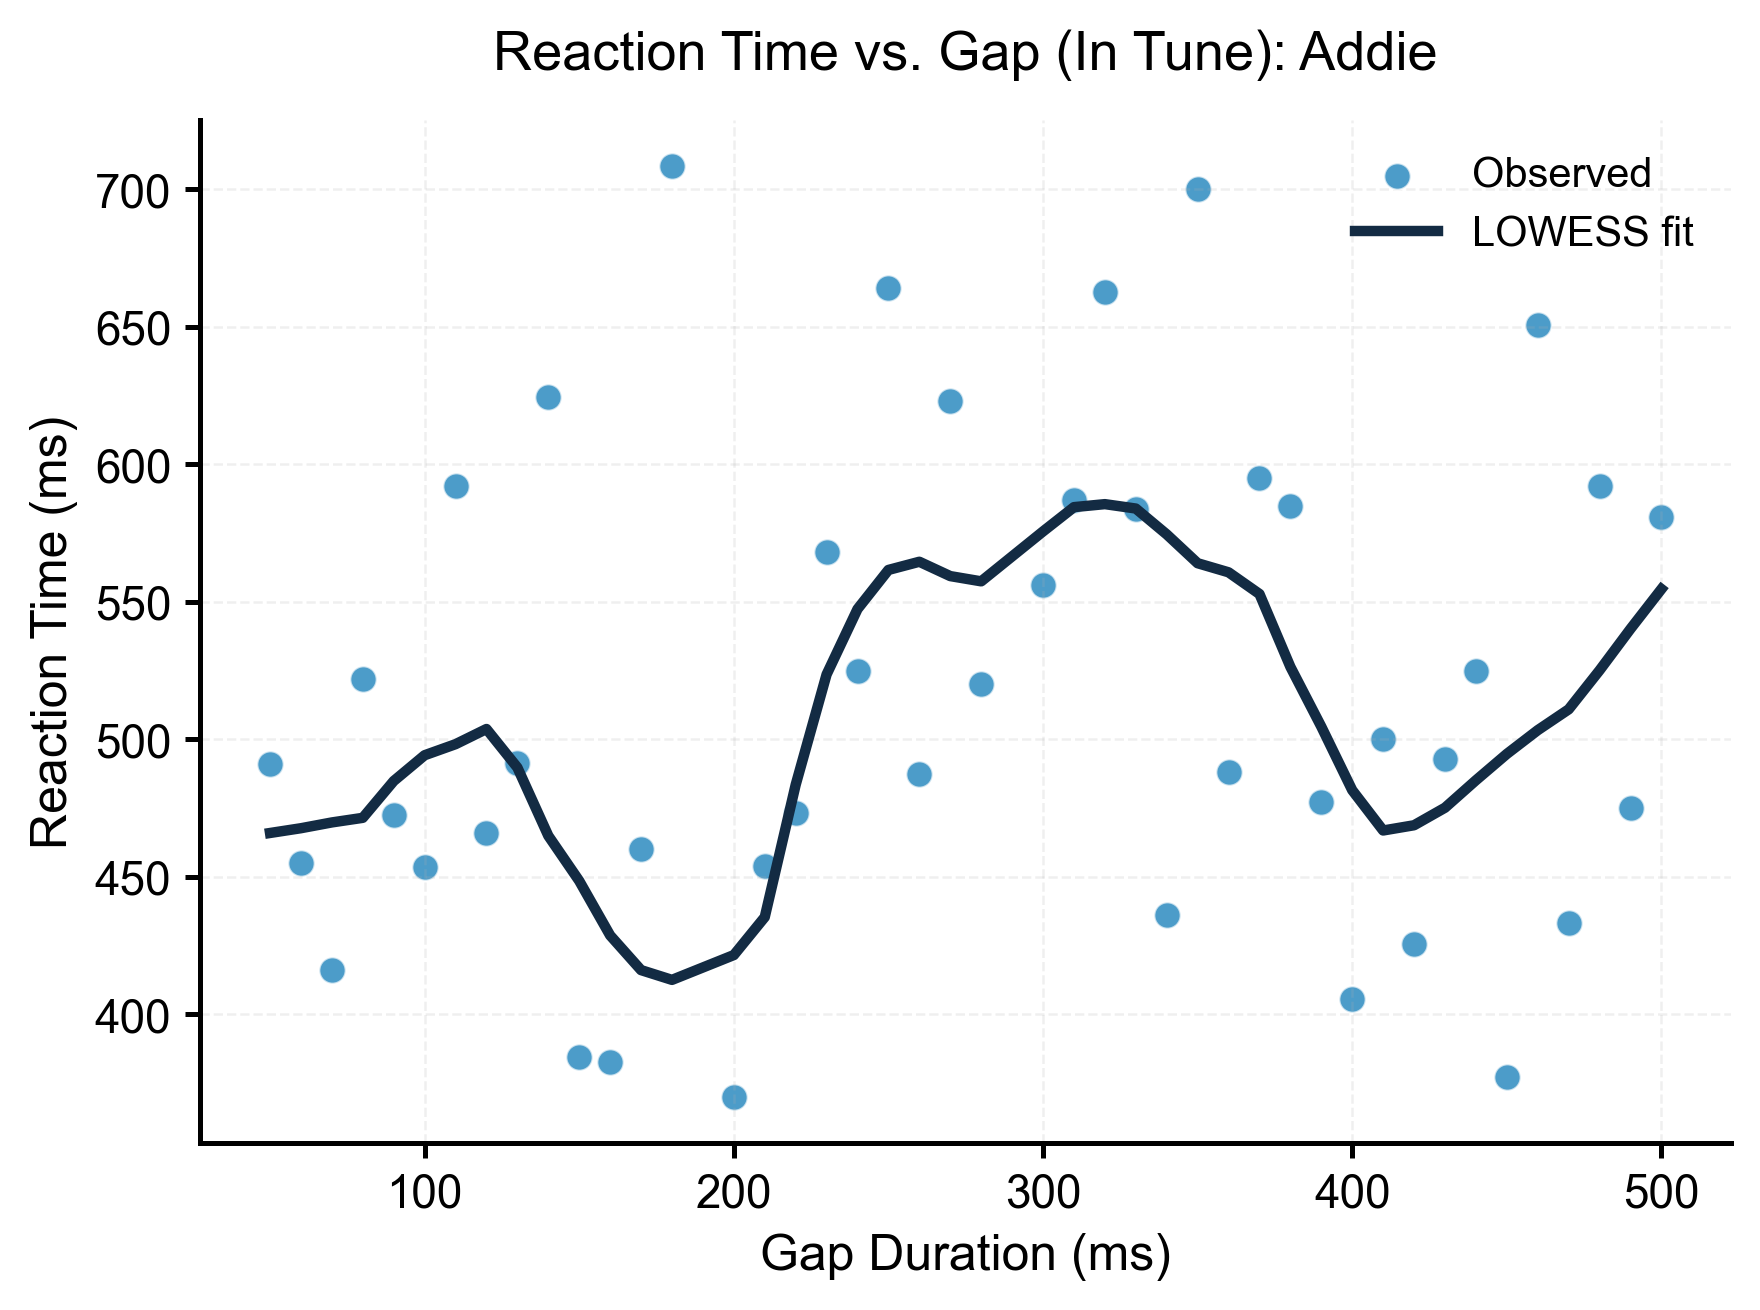

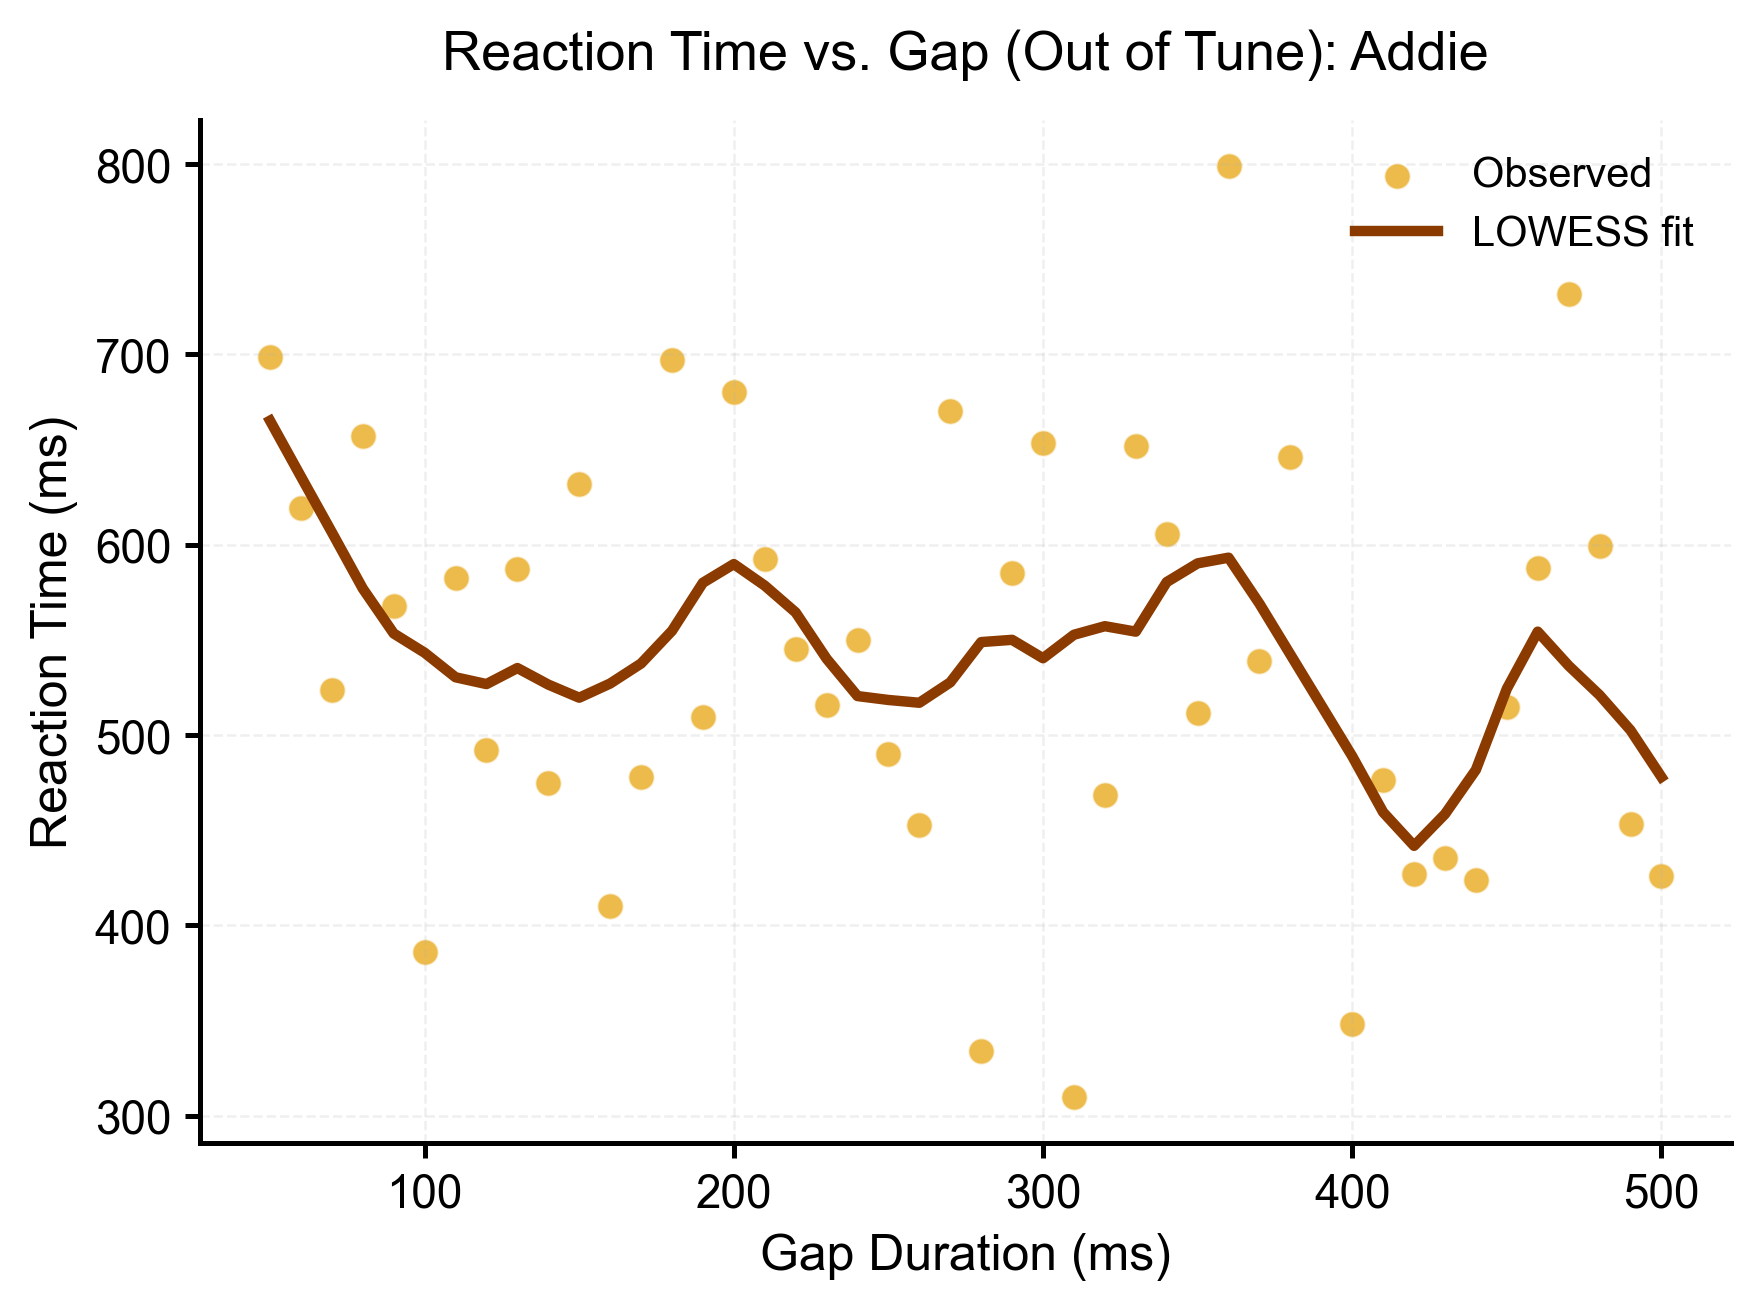

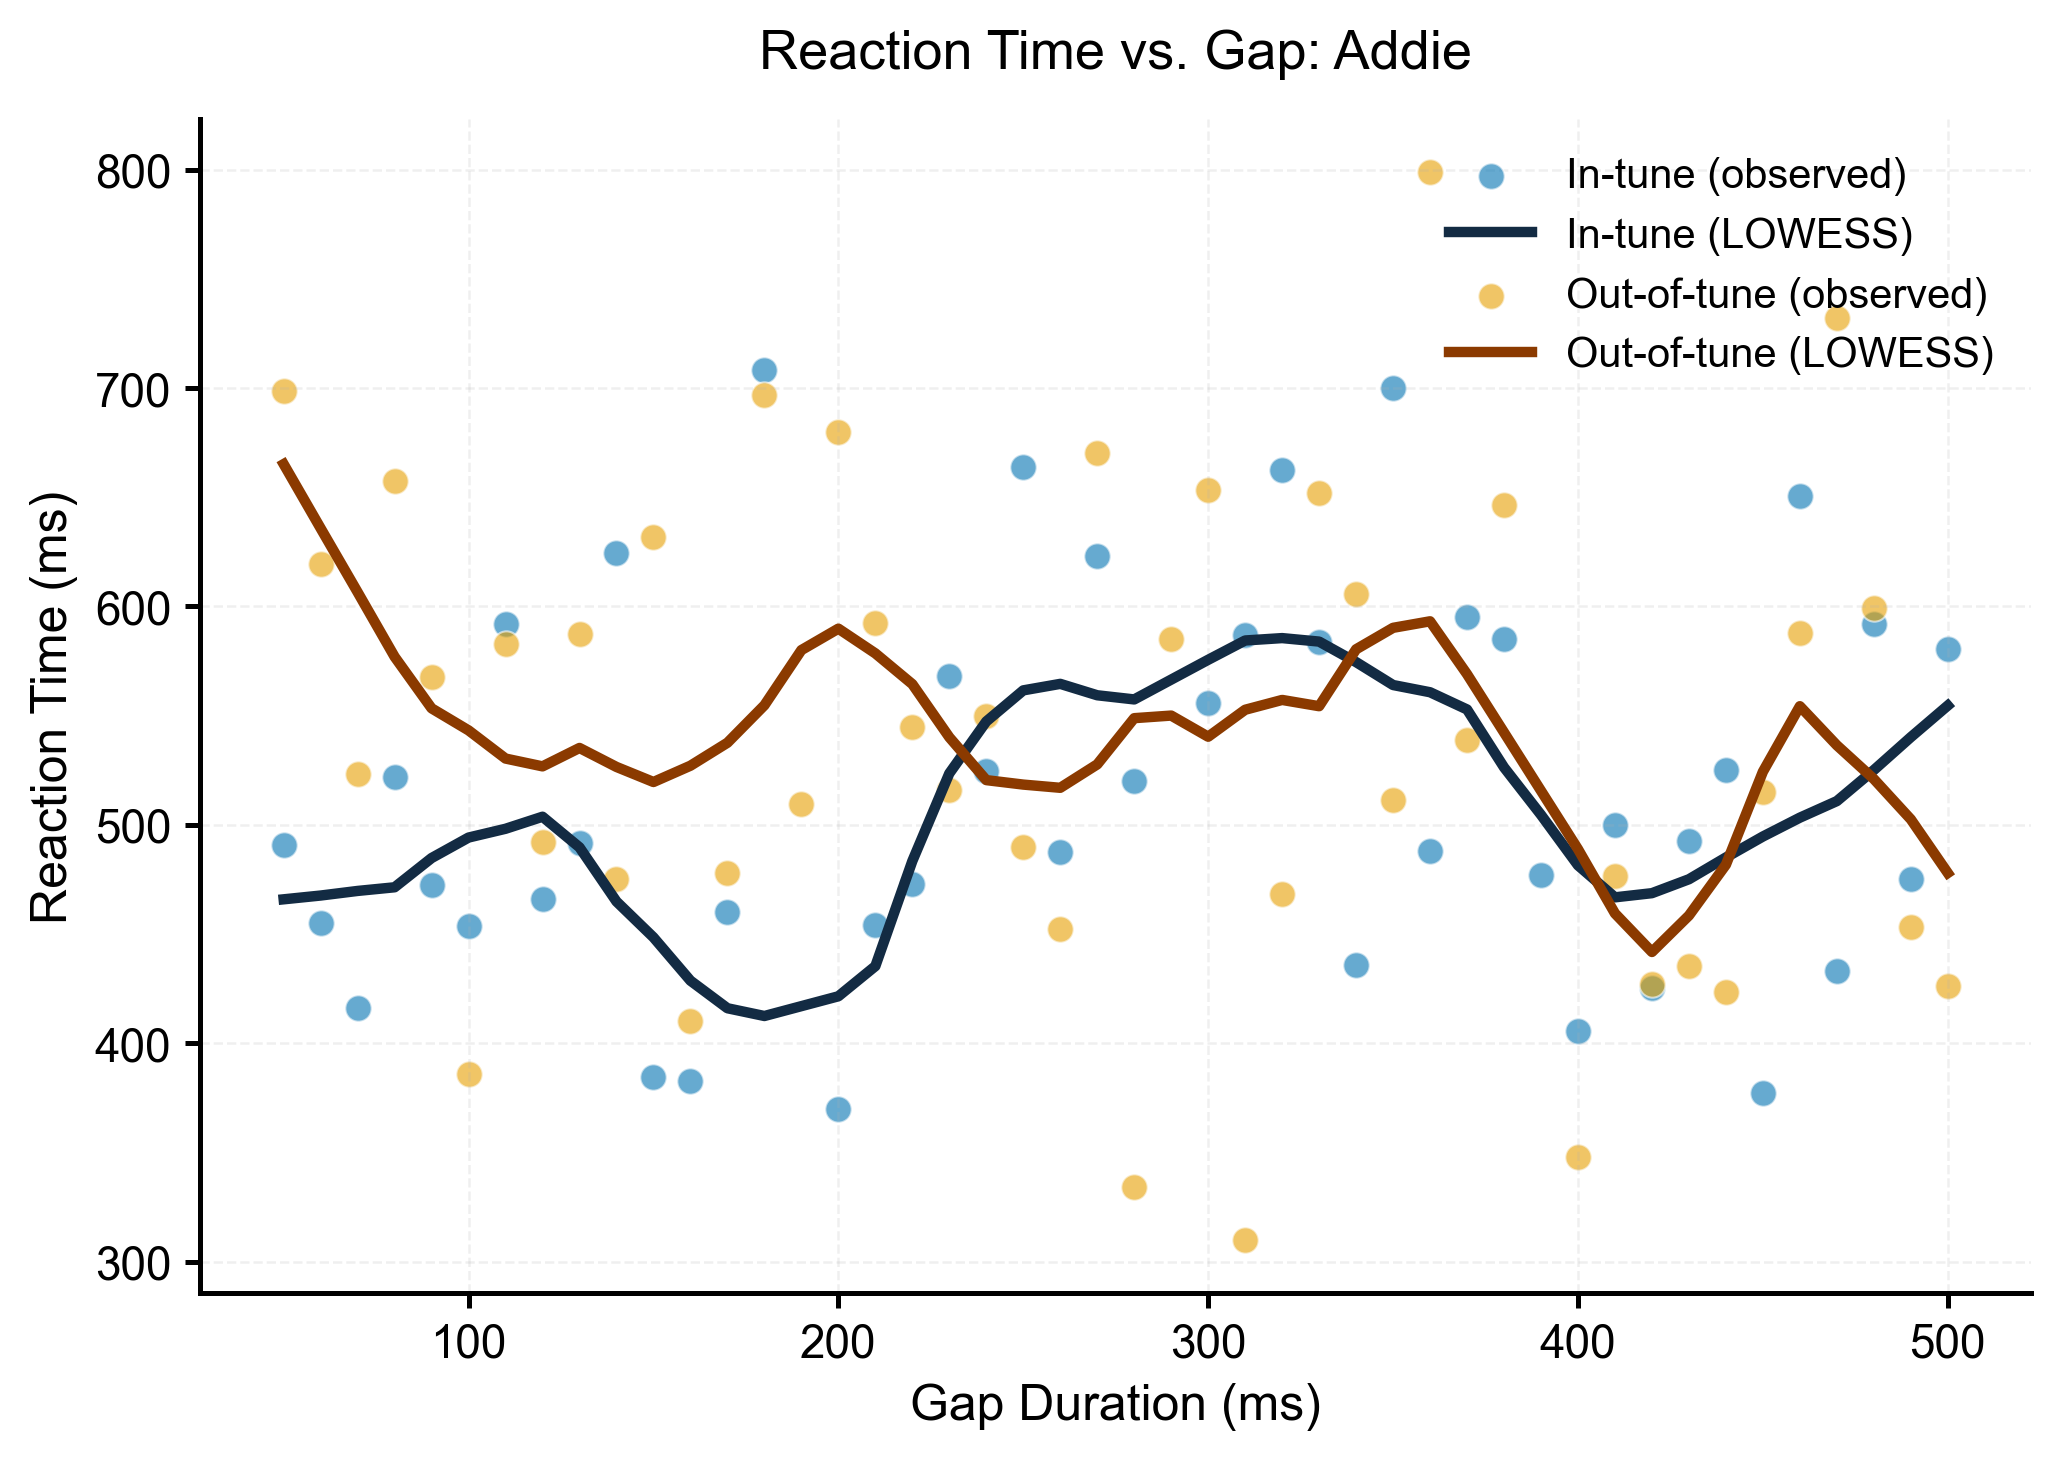

In [4]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt
import pandas as pd
import os

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2
})

base_dir = "/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged"
in_path = f"{base_dir}/{participant_name}/{participant_name}_inavg.csv"
out_path = f"{base_dir}/{participant_name}/{participant_name}_outavg.csv"

in_tune_df = pd.read_csv(in_path)
out_of_tune_df = pd.read_csv(out_path)

in_rt_column = [col for col in in_tune_df.columns if 'InAveRT' in col][0]
out_rt_column = [col for col in out_of_tune_df.columns if 'OutAveRT' in col][0]

# Apply LOWESS smoothing
frac = 0.2
maha_smooth_in = lowess(in_tune_df[in_rt_column], in_tune_df['Gap'], frac=frac)
maha_smooth_out = lowess(out_of_tune_df[out_rt_column], out_of_tune_df['Gap'], frac=frac)


color_intune = '#0072B2'          # Deep blue (in-tune scatter)
color_intune_smooth = '#132B43'   # Navy (in-tune line)
color_outtune = '#E69F00'         # Warm amber (out-of-tune scatter)
color_outtune_smooth = '#8B3A00'  # Burnt umber (out-of-tune line)

# === Plot In-Tune ===
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(in_tune_df['Gap'], in_tune_df[in_rt_column],
           color=color_intune, s=40, alpha=0.7, edgecolors='white',
           linewidth=0.5, label="Observed")
ax.plot(maha_smooth_in[:, 0], maha_smooth_in[:, 1],
        color=color_intune_smooth, linewidth=2.5,
        label="LOWESS fit")

ax.set_xlabel("Gap Duration (ms)")
ax.set_ylabel("Reaction Time (ms)")
ax.set_title(f"Reaction Time vs. Gap (In Tune): {participant_name.title()}", pad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.6)
ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.savefig(f'Reaction Time vs. Gap (In Tune): {participant_name.title()}.png', bbox_inches='tight')
plt.show()

# === Plot Out-of-Tune ===
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(out_of_tune_df['Gap'], out_of_tune_df[out_rt_column],
           color=color_outtune, s=40, alpha=0.7, edgecolors='white',
           linewidth=0.5, label="Observed")
ax.plot(maha_smooth_out[:, 0], maha_smooth_out[:, 1],
        color=color_outtune_smooth, linewidth=2.5,
        label="LOWESS fit")

ax.set_xlabel("Gap Duration (ms)")
ax.set_ylabel("Reaction Time (ms)")
ax.set_title(f"Reaction Time vs. Gap (Out of Tune): {participant_name.title()}", pad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.6)
ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.savefig(f'Reaction Time vs. Gap (Out of Tune): {participant_name.title()}.png', bbox_inches='tight')
plt.show()

# === Combined Plot ===
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(in_tune_df['Gap'], in_tune_df[in_rt_column],
           color=color_intune, s=40, alpha=0.6, edgecolors='white',
           linewidth=0.5, label="In-tune (observed)")
ax.plot(maha_smooth_in[:, 0], maha_smooth_in[:, 1],
        color=color_intune_smooth, linewidth=2.5, label="In-tune (LOWESS)")

ax.scatter(out_of_tune_df['Gap'], out_of_tune_df[out_rt_column],
           color=color_outtune, s=40, alpha=0.6, edgecolors='white',
           linewidth=0.5, label="Out-of-tune (observed)")
ax.plot(maha_smooth_out[:, 0], maha_smooth_out[:, 1],
        color=color_outtune_smooth, linewidth=2.5, label="Out-of-tune (LOWESS)")

ax.set_xlabel("Gap Duration (ms)")
ax.set_ylabel("Reaction Time (ms)")
ax.set_title(f"Reaction Time vs. Gap: {participant_name.title()}", pad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.6)
ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.savefig(f'Reaction Time vs. Gap: {participant_name.title()}.png', bbox_inches='tight')
plt.show()

In-Tune Mean: 506.55 ms, SD: 49.89 ms
Out-of-Tune Mean: 542.25 ms, SD: 43.47 ms


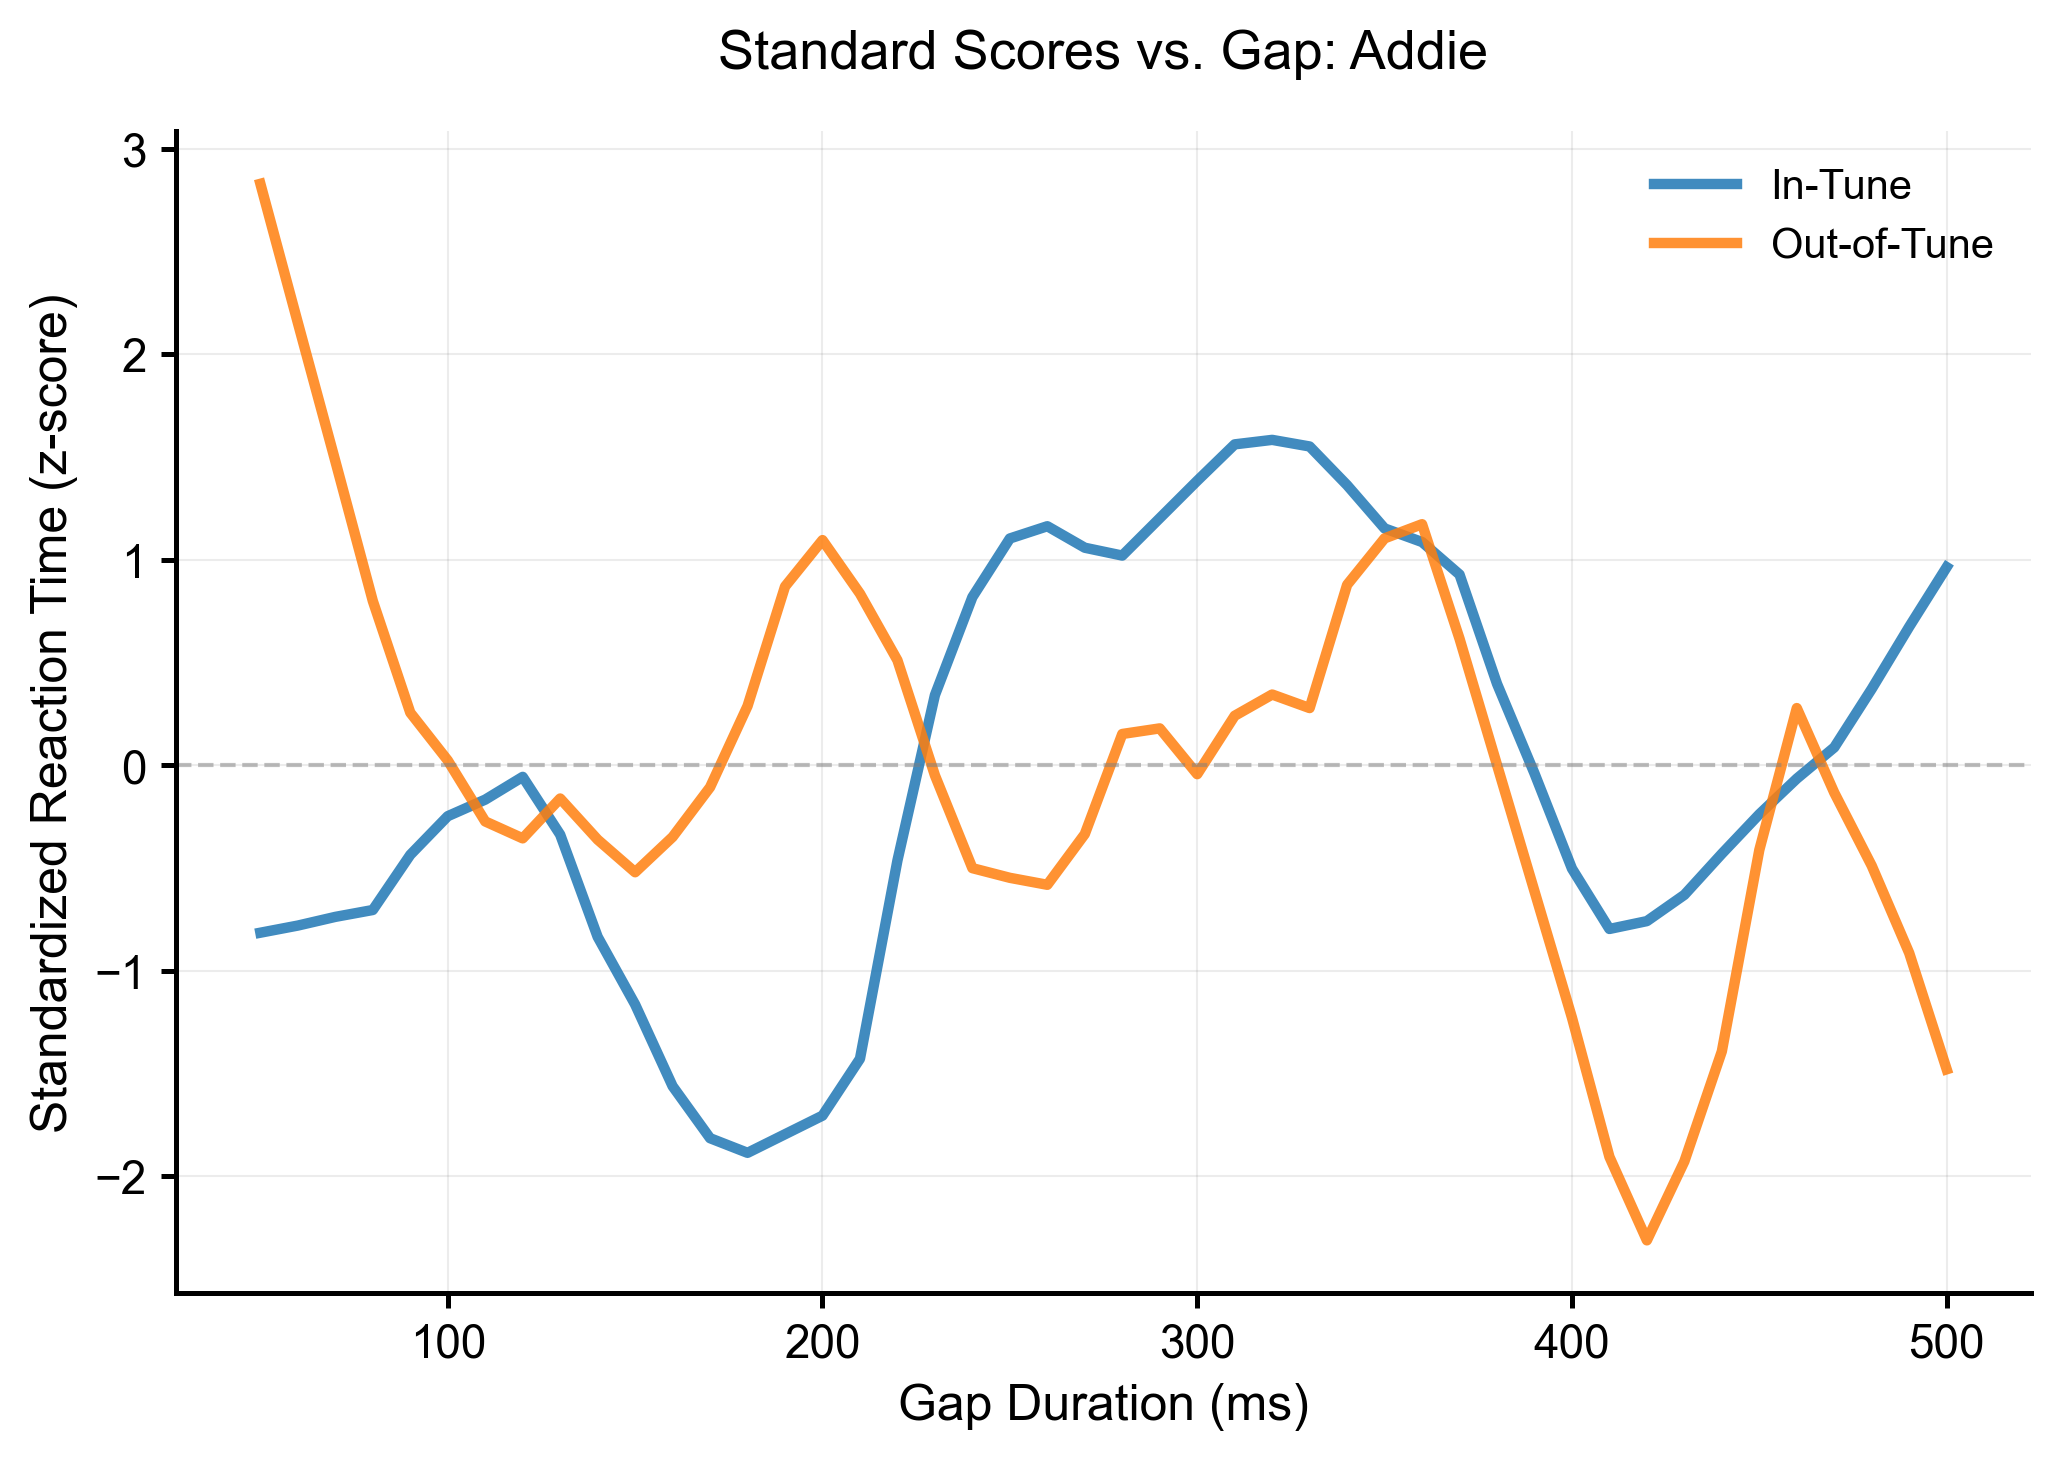


Z-score statistics:
In-Tune Z-score range: [-1.89, 1.58]
Out-of-Tune Z-score range: [-2.31, 2.83]


In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import os

# Set consistent plotting style
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2
})

project_root = Path().resolve().parents[1]
base_dir = project_root / "data"

in_path = base_dir / "averaged" / participant_name / f"{participant_name}_inavg.csv"
out_path = base_dir / "averaged" / participant_name / f"{participant_name}_outavg.csv"

# Read data
in_tune_df = pd.read_csv(in_path)
out_of_tune_df = pd.read_csv(out_path)

# Find relevant columns
in_rt_column = [col for col in in_tune_df.columns if 'InAveRT' in col][0]
out_rt_column = [col for col in out_of_tune_df.columns if 'OutAveRT' in col][0]

# Rename for consistency
in_tune_df = in_tune_df.rename(columns={in_rt_column: 'InAveRT'})
out_of_tune_df = out_of_tune_df.rename(columns={out_rt_column: 'OutAveRT'})

# Apply LOWESS smoothing
frac = 0.2
maha_smooth_in = pd.DataFrame(
    lowess(in_tune_df['InAveRT'], in_tune_df['Gap'], frac=frac), 
    columns=['Gap', 'InAveRT']
)
maha_smooth_out = pd.DataFrame(
    lowess(out_of_tune_df['OutAveRT'], out_of_tune_df['Gap'], frac=frac), 
    columns=['Gap', 'OutAveRT']
)

# Compute mean and SD for standardization
in_tune_mean = maha_smooth_in['InAveRT'].mean()
in_tune_sd = maha_smooth_in['InAveRT'].std()
out_of_tune_mean = maha_smooth_out['OutAveRT'].mean()
out_of_tune_sd = maha_smooth_out['OutAveRT'].std()

print(f"In-Tune Mean: {in_tune_mean:.2f} ms, SD: {in_tune_sd:.2f} ms")
print(f"Out-of-Tune Mean: {out_of_tune_mean:.2f} ms, SD: {out_of_tune_sd:.2f} ms")

# Standard scores
maha_smooth_in['InAveRT_Z'] = (maha_smooth_in['InAveRT'] - in_tune_mean) / in_tune_sd
maha_smooth_out['OutAveRT_Z'] = (maha_smooth_out['OutAveRT'] - out_of_tune_mean) / out_of_tune_sd

# Save smoothed data (relative paths)
save_dir = base_dir / "smoothed" / participant_name
save_dir.mkdir(parents=True, exist_ok=True)

maha_smooth_in.to_csv(save_dir / f"{participant_name}_intune_smoothed.csv", index=False)
maha_smooth_out.to_csv(save_dir / f"{participant_name}_outtune_smoothed.csv", index=False)

# Colors consistent with Matplotlib defaults
color_intune = plt.get_cmap("tab10")(0)  # same as 'tab:blue'
color_outtune = plt.get_cmap("tab10")(1)  # same as 'tab:orange'

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(maha_smooth_in['Gap'], maha_smooth_in['InAveRT_Z'], 
        color=color_intune, linewidth=2.5, label='In-Tune', alpha=0.85)
ax.plot(maha_smooth_out['Gap'], maha_smooth_out['OutAveRT_Z'], 
        color=color_outtune, linewidth=2.5, label='Out-of-Tune', alpha=0.85)

ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel('Gap Duration (ms)')
ax.set_ylabel('Standardized Reaction Time (z-score)')
ax.set_title(f'Standard Scores vs. Gap: {participant_name.title()}', pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.15, linestyle='-', linewidth=0.5, color='gray')
ax.legend(frameon=False, loc='best')

plt.tight_layout()
plt.savefig(f"Standard Scores vs. Gap: {participant_name.title()}.png", format='png', bbox_inches='tight')
plt.show()

# Range summary
print(f"\nZ-score statistics:")
print(f"In-Tune Z-score range: [{maha_smooth_in['InAveRT_Z'].min():.2f}, {maha_smooth_in['InAveRT_Z'].max():.2f}]")
print(f"Out-of-Tune Z-score range: [{maha_smooth_out['OutAveRT_Z'].min():.2f}, {maha_smooth_out['OutAveRT_Z'].max():.2f}]")
